<a href="https://colab.research.google.com/github/Rustam99-eng/Music-Generation/blob/main/Music_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Произведем последовательную установку следующих компонентов:

*   fluidsynth — программный синтезатор для преобразования MIDI в аудиосигнал;
*   pyfluidsynth — Python-обертка для FluidSynth, обеспечивающая управление синтезатором из кода на Python;

In [ ]:
!sudo apt install -y fluidsynth
!pip install --upgrade pyfluidsynth

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core fluid-soundfont-gm gsettings-desktop-schemas libatk-bridge2.0-0
  libatk1.0-0 libatk1.0-data libatspi2.0-0 libdouble-conversion3 libevdev2
  libfluidsynth3 libgtk-3-0 libgtk-3-bin libgtk-3-common libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5
  librsvg2-common libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 qsynth qt5-gtk-platformtheme
  qttranslations5-l10n session-migration timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs gvfs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  at-spi2-core fluid-soundfont

Подготовим окружение для задач вычислительной музыкологии — установим нотный редактор MuseScore 3 (который Music21 может вызывать для отображения или экспорта нот) и саму библиотеку Music21 строго определённой версии.

In [ ]:
!add-apt-repository -y ppa:mscore-ubuntu/mscore3-stable
!apt-get update
!apt-get install musescore3
!pip install -U music21==9.1.0

Repository: 'deb https://ppa.launchpadcontent.net/mscore-ubuntu/mscore3-stable/ubuntu/ jammy main'
Description:
~~~~~~~~~ MUSESCORE 3 RELEASES FOR UBUNTU 18.04 AND LATER ~~~~~~~~~
Note that Canonical doesn’t allow new builds for releases marked obsolete
(any nōn-LTS predating the previous LTS (currently 24.04 “noble”), and any LTS
older than 7 years, currently anything before 14.04 “trusty”). The packages
for those older releases here can no longer be updated but still work, within
limitations. Best to upgrade to a supported release of the operating system!

INSTALLING: (run these commands from the terminal)
  sudo add-apt-repository ppa:mscore-ubuntu/mscore3-stable
  sudo apt-get update
  sudo apt-get install musescore3

DO *NOT* USE THESE PPAs on Debian, only on Ubuntu!

‣‣‣ These packages are NOT suitable for ”KDE neon 18.04 (bionic)”!
‣ Use https://build.opensuse.org/project/show/home:mirabile:mscore instead.
⚠ KDE neon 18.04 was discontinued so those packages can no longer be upda

In [ ]:
!apt-get install xvfb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 59 not upgraded.


In [ ]:
from music21 import *

# настраиваем окружение в соответствии с документацией
us = environment.UserSettings()
us['musescoreDirectPNGPath'] = '/usr/bin/mscore3'
us['directoryScratch'] = '/tmp'

In [ ]:
!pip install numpy  # Устанавливаем совместимую версию numpy
!pip install tensorflow  # Переустанавливаем tensorflow после этого

In [ ]:
# Импортируем библиотеки
import tensorflow
import os
import numpy as np
import pandas as pd
from collections import Counter
import random
import IPython
from IPython.display import Image, Audio
import music21
from music21 import *
import fluidsynth

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import keras.backend as K
from keras.optimizers import Adamax

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import sys
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
np.random.seed(42)

In [ ]:
# Устанавливаем датасет с классической музыкой
!wget https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip

--2026-04-05 12:45:57--  https://storage.yandexcloud.net/academy.ai/classical-music-midi.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2751606 (2.6M) [application/x-zip-compressed]
Saving to: ‘classical-music-midi.zip’

classical-music-mid 100%[===================>]   2.62M  2.09MB/s    in 1.3s    

2026-04-05 12:45:59 (2.09 MB/s) - ‘classical-music-midi.zip’ saved [2751606/2751606]



In [ ]:
# Разархивируем датасета во временную папку 'dataset'
!unzip -qo "classical-music-midi" -d ./dataset

In [ ]:
!dir ./dataset

Albeniz    Brahms	Debussy   Liszt        Rachmaninoff  Tchaikovsky
Bach	   Burgmueller	Godowsky  Mendelssohn  Ravel
Balakirev  Chopin	Granados  Moszkowski   Schubert
Beethoven  Christmas	Grieg	  Mozart       Schumann
Borodin    Clementi	Haydn	  Mussorgsky   Sinding


In [ ]:
CLASS_Chopin=["Chopin"]
CLASS_Mozart=["Mozart"]

In [ ]:
chopin_midis = []
mozart_midis = []
filepath_1 = f"./dataset/Chopin/"
filepath_2 = f"./dataset/Mozart/"

for i in os.listdir(filepath_1):
  if i.endswith(".mid"):
    tr = filepath_1+i

    # чтение и парсинг midi-файлов в Stream-объект библиотеки music21
    midi = converter.parse(tr)
    chopin_midis.append(midi)

for i in os.listdir(filepath_2):
  if i.endswith(".mid"):
    tr = filepath_2+i

    # чтение и парсинг midi-файлов в Stream-объект библиотеки music21
    midi = converter.parse(tr)
    mozart_midis.append(midi)

Объявим функцию для преобразования потока Stream midi-файлов в список нот, а точнее их тональностей (тонов).

In [ ]:
def getNotes(file):
    notes = []
    notes_to_parse = None
    for j in file:

        # получение инструментов из Stream-объекта
        songs = instrument.partitionByInstrument(j)

        # цикл по всем инструментам
        for part in songs.parts:
            # используем рекурсивный итератор в соответствии с документацией
            notes_to_parse = part.recurse()
            # части Stream-объекта, с которым мы работает состоит из разных элементов
            # отберем только интересующие нас элементы note.Note (нота) и chord.Chord (целый аккорд, последовательность нот)
            for element in notes_to_parse:
                if isinstance(element, note.Note):
                    # извлекаем ноту как тон (терминология библиотеки)
                    notes.append(str(element.pitch))
                elif isinstance(element, chord.Chord):
                    # аккорд функционирует как объект-нота, но имеет несколько последовательных тонов
                    notes.append(".".join(str(n) for n in element.normalOrder))

    return notes

In [ ]:
chopin_corpus = getNotes(chopin_midis)
print("Всего нот в midi-файлах в папке Шопен:", len(chopin_corpus))

mozart_corpus = getNotes(mozart_midis)
print("Всего нот в midi-файлах в папке Моцарт:", len(mozart_corpus))

Всего нот в midi-файлах в папке Шопен: 57894
Всего нот в midi-файлах в папке Моцарт: 55802


In [ ]:
print("Первые 50 нот в корпусе Шопен:", chopin_corpus[:50])
print("Первые 50 нот в корпусе Моцарт:", mozart_corpus[:50])

Первые 50 нот в корпусе Шопен: ['E4', 'C#5', 'E2', 'D5', '8.11.2', '4', '8.11.2', '4', '8.11.2', '4', '2.6', '0.3', 'A2', '1.4', '9.1', '4.9', '9.1', '4.9', '9.1', '4.9', '1.4', '10.1', 'E2', 'D4', 'B4', '2.6', '11.4', '2.6', '11.4', '2.6', 'D4', '11.4', '2.8', '2.8', 'A1', '9.1', '1', '4.9', '1', '4.9', '1', '4.9', 'E4', '8.1', 'E4', 'E2', 'D5', '8.11.2', '4', '8.11.2']
Первые 50 нот в корпусе Моцарт: ['7.10', '3', '3.7', '5.10', 'B-2', '3.7', 'E-3', 'B-3', 'E-4', '2.5', 'B-2', 'E-4', 'G4', 'E-3', 'G#4', 'C3', 'B-4', 'G2', 'C5', 'G#2', '3.7', 'B-2', 'G#4', 'D4', 'F4', 'G4', 'G#4', 'A4', 'B-4', 'B-5', 'G4', 'G5', 'E-4', 'F5', 'B-3', '10.3', 'G3', '2.5', 'B-3', '3.7', 'E-4', '3.8', 'C4', '10.3', 'G3', '11.0', '5.8', '5.8', 'E-5', 'B-3']


In [ ]:
# Функция преобразования отрывка из корпуса обратно в поток
def chords_n_notes(chunk):
    Melody = []
    offset = 0 # счетчик
    for i in chunk:
        # Если это аккорд разделенный точкой
        if ("." in i or i.isdigit()):
            chord_notes = i.split(".") # Разделяем аккорд на части
            notes = []
            for j in chord_notes:
                inst_note=int(j)
                # Преобразуем ноту в обект Note (нота)
                note_chunk = note.Note(inst_note)
                notes.append(note_chunk)
                # объединяем ноты в аккорды
                chord_chunk = chord.Chord(notes)
                # задаем позицию аккорда
                chord_chunk.offset = offset
                Melody.append(chord_chunk)
        # если это нота, а не аккорд
        else:
            # из текстового обозначения ноты делаем объект Note (ноту)
            note_chunk = note.Note(i)
            # задаем позицию ноты
            note_chunk.offset = offset
            Melody.append(note_chunk)
        # увеличиваем номер позиции
        offset += 1


    return Melody

# Преобразуем последовательность из 100 нот обратно в поток Stream
Music_chopin = chords_n_notes(chopin_corpus[:100])
Melody_midi_chopin = stream.Stream(Music_chopin)

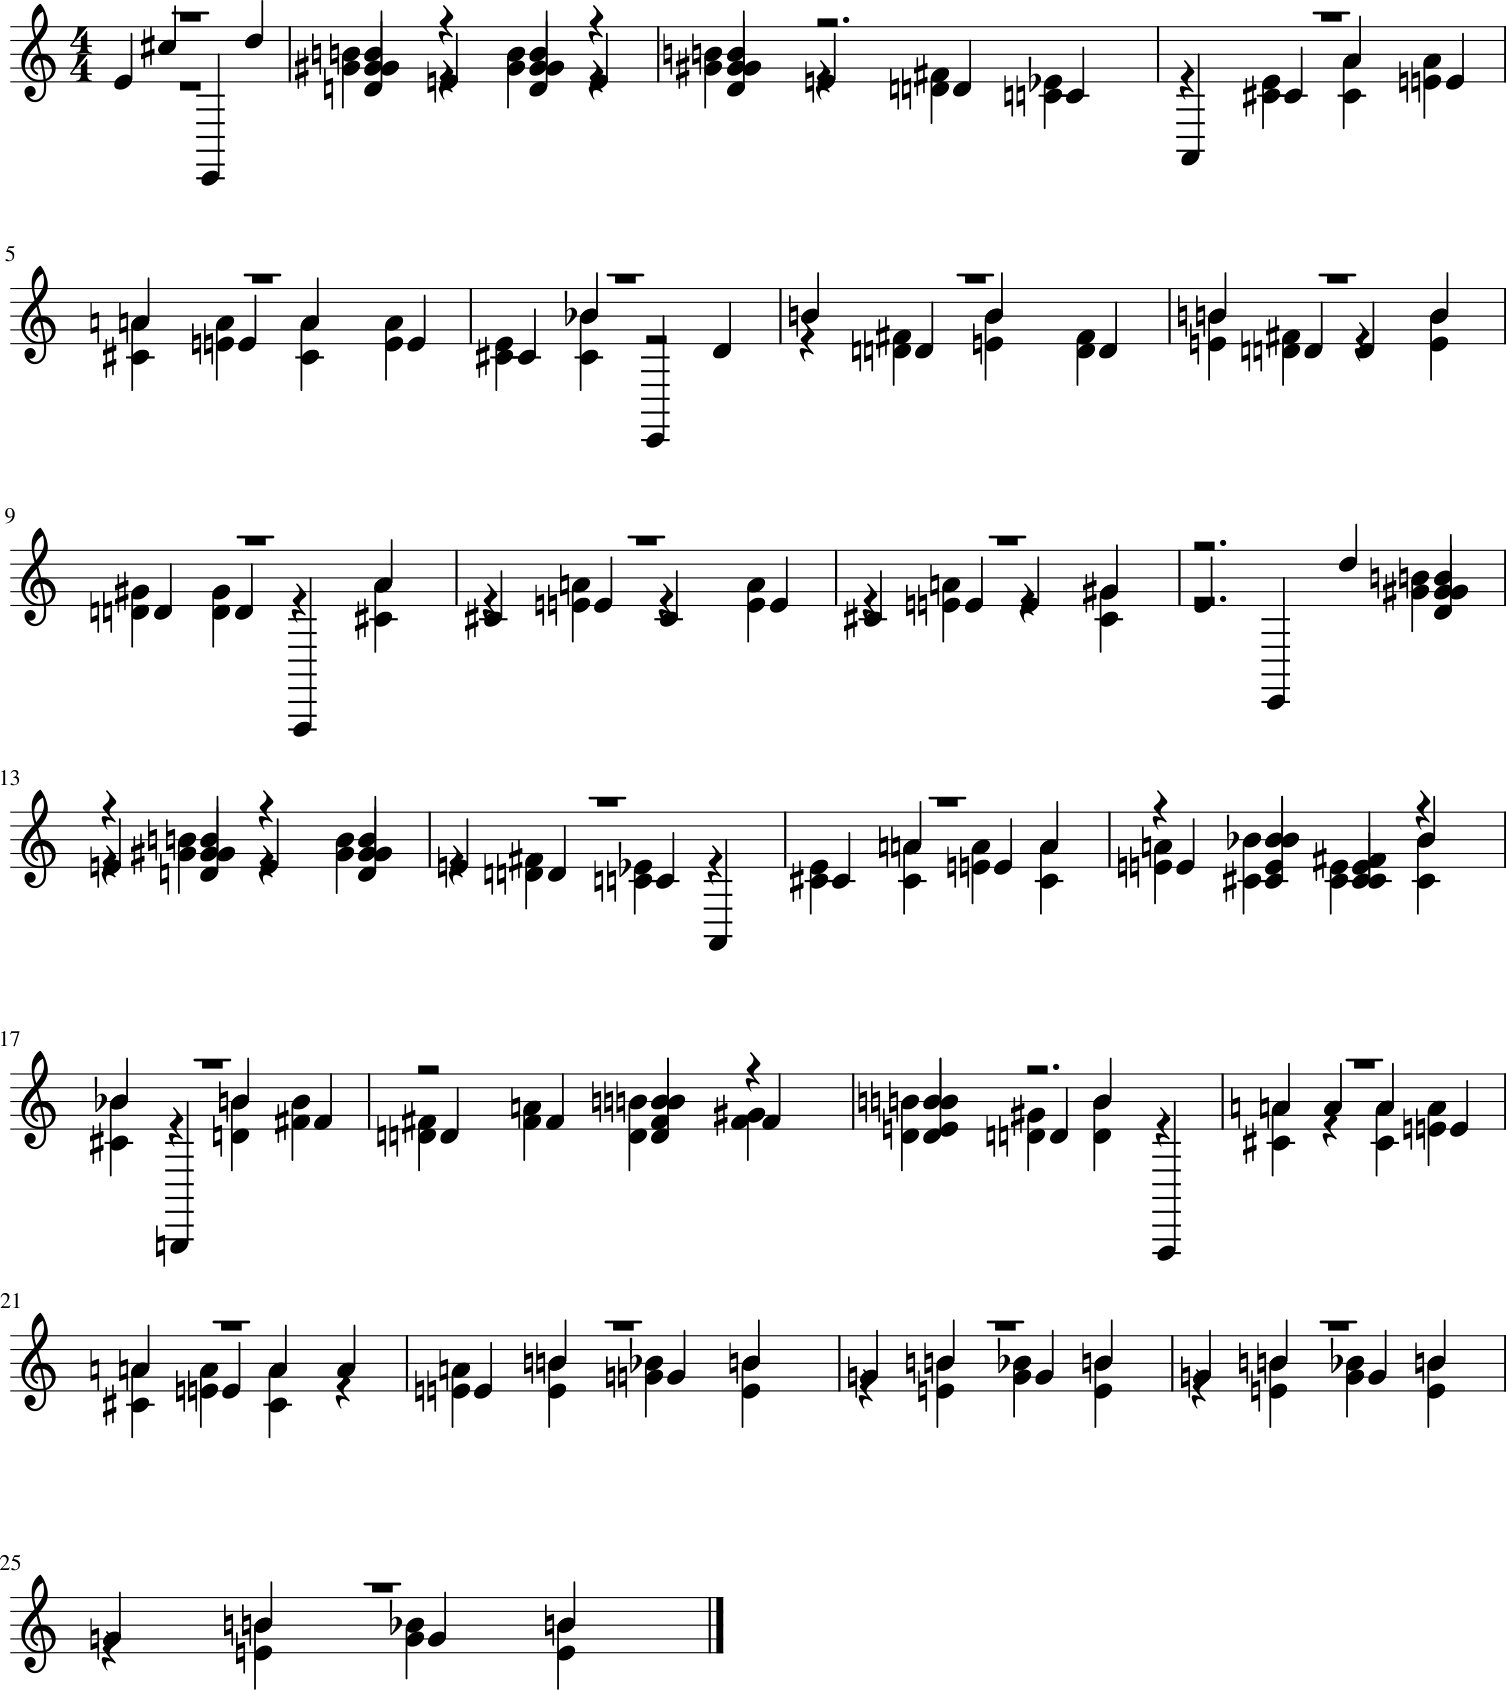

In [ ]:
# Отобразим нотный стан
Melody_midi_chopin.show()

In [ ]:
# Выведем в виде звуковой дорожки
Melody_midi_chopin.show('midi')

Изучим частоту появления нот в мелодии и избавимся от наиболее редких нот

In [ ]:
from collections import Counter
count_num_chopin = Counter(chopin_corpus)
count_num_mozart = Counter(mozart_corpus)
print("Общее число уникальных нот в корпусе Шопен:", len(count_num_chopin))
print("Общее число уникальных нот в корпусе Моцарт:", len(count_num_mozart))

Общее число уникальных нот в корпусе Шопен: 397
Общее число уникальных нот в корпусе Моцарт: 229


In [ ]:
# Ключ в словаре - имена нот
# Значение в словаре - их количество

Notes_chopin = list(count_num_chopin.keys())
Recurrence_chopin = list(count_num_chopin.values())

Notes_mozart = list(count_num_mozart.keys())
Recurrence_mozart = list(count_num_mozart.values())

# Средняя частота встречаемости нот в корпусе
def Average(rec):
    return sum(rec) / len(rec)

print('Средняя повторяемость ноты у Шопена:', Average(Recurrence_chopin))
print('Наиболее часто встречаемые ноты у Шопена:', max(Recurrence_chopin), 'раз')
print('Наиболее редкие ноты у Шопена:', min(Recurrence_chopin), 'раз')
print()
print('Средняя повторяемость ноты у Моцарта:', Average(Recurrence_mozart))
print('Наиболее часто встречаемые ноты у Моцарта:', max(Recurrence_mozart), 'раз')
print('Наиболее редкие ноты у Моцарта:', min(Recurrence_mozart), 'раз')

Средняя повторяемость ноты у Шопена: 145.8287153652393
Наиболее часто встречаемые ноты у Шопена: 1627 раз
Наиболее редкие ноты у Шопена: 1 раз

Средняя повторяемость ноты у Моцарта: 243.6768558951965
Наиболее часто встречаемые ноты у Моцарта: 2355 раз
Наиболее редкие ноты у Моцарта: 1 раз


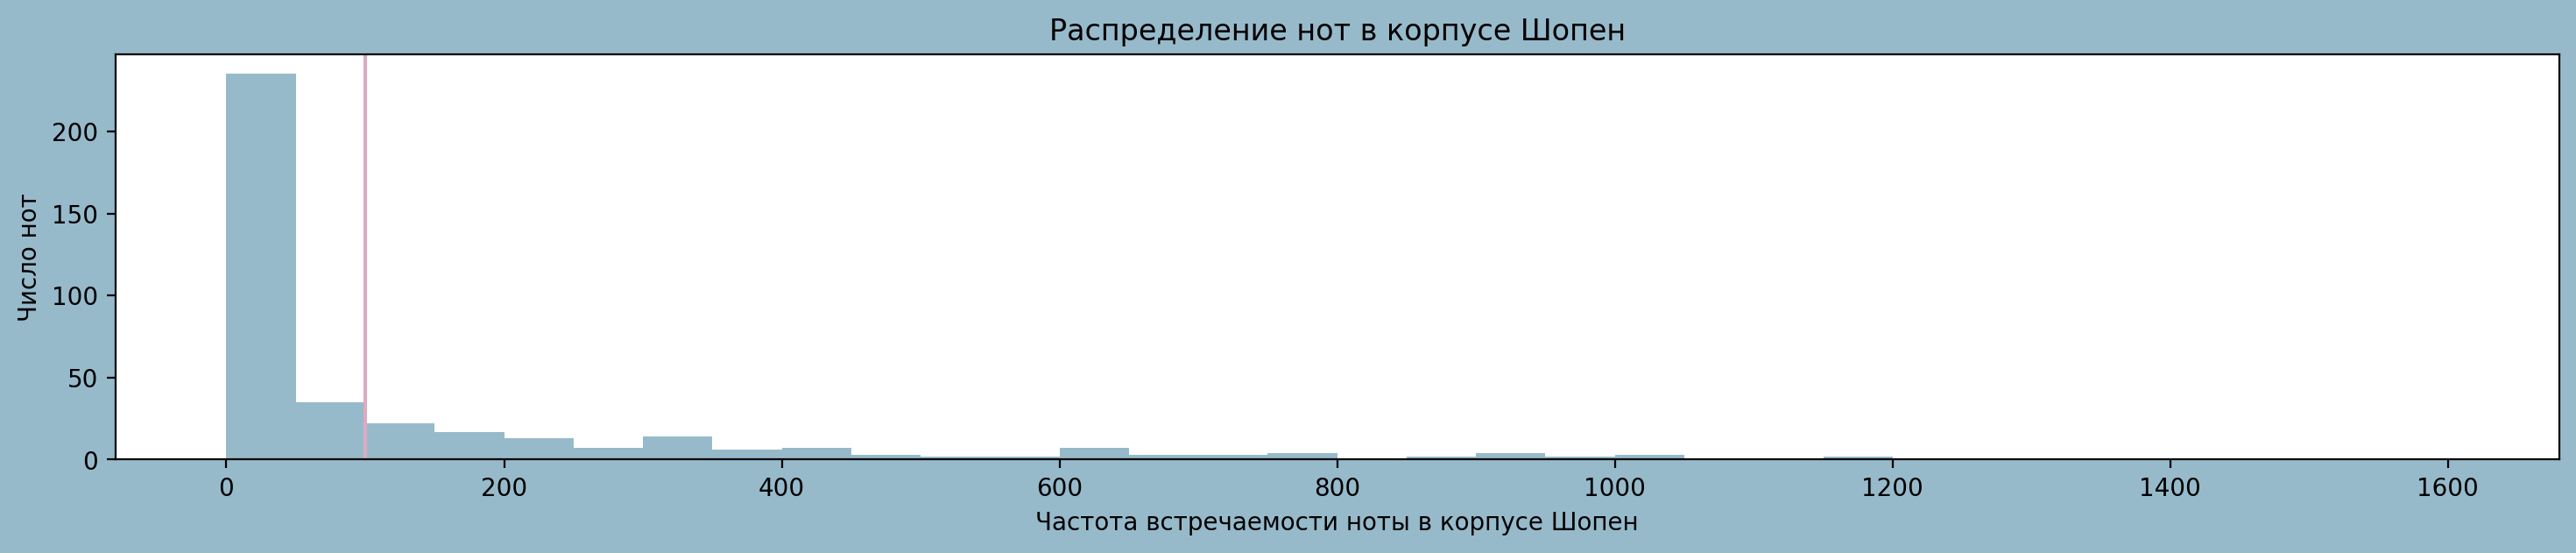

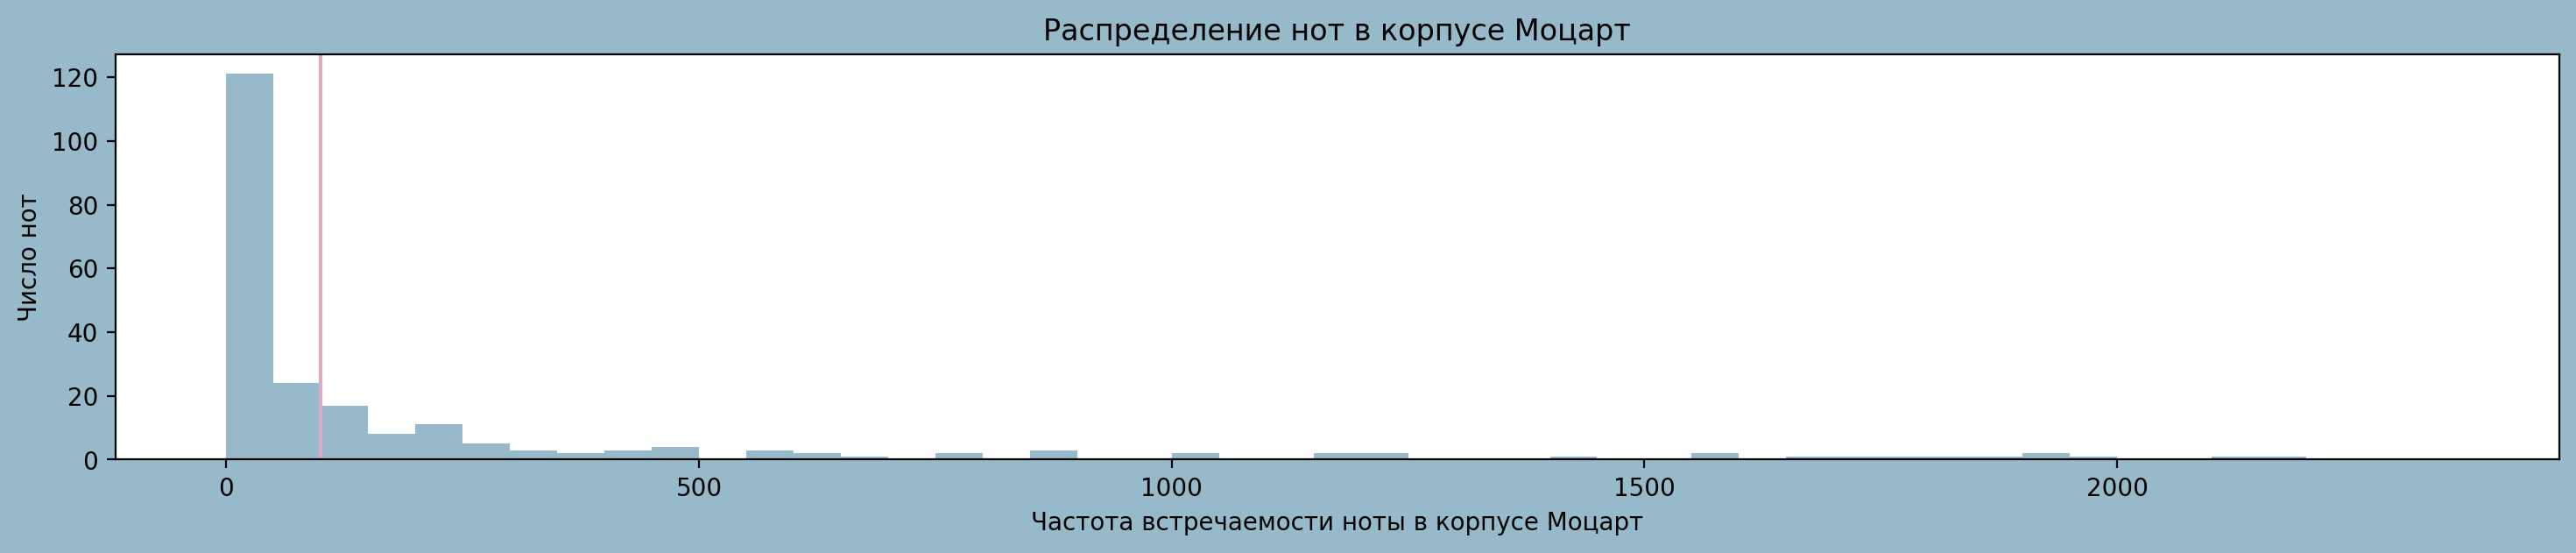

In [ ]:
plt.figure(figsize=(18, 3), facecolor='#97BACB')
bins = np.arange(0,(max(Recurrence_chopin)), 50)
plt.hist(Recurrence_chopin, bins=bins, color='#97BACB')
plt.axvline(x=100, color='#DBACC1') # отсечка по встречаемости в 100 раз
plt.title('Распределение нот в корпусе Шопен')
plt.xlabel('Частота встречаемости ноты в корпусе Шопен')
plt.ylabel('Число нот')
plt.show()

plt.figure(figsize=(18, 3), facecolor='#97BACB')
bins = np.arange(0,(max(Recurrence_mozart)), 50)
plt.hist(Recurrence_mozart, bins=bins, color='#97BACB')
plt.axvline(x=100, color='#DBACC1') # отсечка по встречаемости в 100 раз
plt.title('Распределение нот в корпусе Моцарт')
plt.xlabel('Частота встречаемости ноты в корпусе Моцарт')
plt.ylabel('Число нот')
plt.show()

In [ ]:
# Получение списка редких нот
rare_note_chopin = []
rare_note_mozart = []
for index, (key, value) in enumerate(count_num_chopin.items()):
    if value < 100:
        m =  key
        rare_note_chopin.append(m)

for index, (key, value) in enumerate(count_num_mozart.items()):
    if value < 100:
        m =  key
        rare_note_mozart.append(m)
print("Общее число нот, которые повторяются менее 100 раз у Шопена:", len(rare_note_chopin))
print("Общее число нот, которые повторяются менее 100 раз у Моцарта:", len(rare_note_mozart))

Общее число нот, которые повторяются менее 100 раз у Шопена: 270
Общее число нот, которые повторяются менее 100 раз у Моцарта: 145


In [ ]:
# Удаление редких нот
for element in chopin_corpus:
    if element in rare_note_chopin:
        chopin_corpus.remove(element)

for element in mozart_corpus:
    if element in rare_note_mozart:
        mozart_corpus.remove(element)

print("Длина корпуса после исключения редких нот у Шопена:", len(chopin_corpus))
print("Длина корпуса после исключения редких нот у Моцарта:", len(mozart_corpus))

Длина корпуса после исключения редких нот у Шопена: 53753
Длина корпуса после исключения редких нот у Моцарта: 53135


In [ ]:
# Сохраняем все уникальные значения корпуса
symb_chopin = sorted(list(set(chopin_corpus)))

L_corpus_chopin = len(chopin_corpus) # длина корпуса
L_symb_chopin = len(symb_chopin) # число уникальных элементов корпуса

# Создание словаря для доступа к словарному запасу из индексов и наоборот
mapping_chopin = dict((c, i) for i, c in enumerate(symb_chopin))
reverse_mapping_chopin = dict((i, c) for i, c in enumerate(symb_chopin))

symb_mozart = sorted(list(set(mozart_corpus)))

L_corpus_mozart = len(mozart_corpus) # длина корпуса
L_symb_mozart = len(symb_mozart) # число уникальных элементов корпуса

# Создание словаря для доступа к словарному запасу из индексов и наоборот
mapping_mozart = dict((c, i) for i, c in enumerate(symb_mozart))
reverse_mapping_mozart = dict((i, c) for i, c in enumerate(symb_mozart))

print("Общее число символов у Шопена:", L_corpus_chopin)
print("Число уникальных символов у Шопена:", L_symb_chopin)
print("Общее число символов у Моцарта:", L_corpus_mozart)
print("Число уникальных символов у Моцарта:", L_symb_mozart)

Общее число символов у Шопена: 53753
Число уникальных символов у Шопена: 263
Общее число символов у Моцарта: 53135
Число уникальных символов у Моцарта: 163


In [ ]:
# Разбиение корпуса на равные входные строки и выходные целевые последовательности

# длинны последовательностей
length = 40

# входные последовательности
features_chopin = []
features_mozart = []

# целевые последовательности
targets_chopin = []
targets_mozart = []

# цикл разбиения корпуса
for i in range(0, L_corpus_chopin - length, 1):
    feature = chopin_corpus[i:i + length]
    target = chopin_corpus[i + length]
    features_chopin.append([mapping_chopin[j] for j in feature])
    targets_chopin.append(mapping_chopin[target])


L_datapoints_chopin = len(targets_chopin)

# цикл разбиения корпуса
for i in range(0, L_corpus_mozart - length, 1):
    feature = mozart_corpus[i:i + length]
    target = mozart_corpus[i + length]
    features_mozart.append([mapping_mozart[j] for j in feature])
    targets_mozart.append(mapping_mozart[target])

L_datapoints_mozart = len(targets_mozart)

print("Общее количество последовательностей в корпусе:", L_datapoints_chopin)
print("Общее количество последовательностей в корпусе:", L_datapoints_mozart)

Общее количество последовательностей в корпусе: 53713
Общее количество последовательностей в корпусе: 53095


In [ ]:
# изменение размера и нормализация входных данных
X_chopin = (np.reshape(features_chopin, (L_datapoints_chopin, length, 1)))/ float(L_symb_chopin)
X_mozart = (np.reshape(features_mozart, (L_datapoints_mozart, length, 1)))/ float(L_symb_mozart)

# one-hot encode для целевых выходных данных
y_chopin = tensorflow.keras.utils.to_categorical(targets_chopin)
y_mozart = tensorflow.keras.utils.to_categorical(targets_mozart)

In [ ]:
print(f'Форма входных данных: {X_chopin.shape}')
print(f'Форма выходных данных: {y_chopin.shape}')
print()
print(f'Форма входных данных: {X_mozart.shape}')
print(f'Форма выходных данных: {y_mozart.shape}')

Форма входных данных: (53713, 40, 1)
Форма выходных данных: (53713, 263)

Форма входных данных: (53095, 40, 1)
Форма выходных данных: (53095, 163)


In [ ]:
# Разделим наборы данных на тренировочные и начальные данные
X_train_chopin, X_seed_chopin, y_train_chopin, y_seed_chopin = train_test_split(X_chopin, y_chopin, test_size=0.2, random_state=42)
X_train_mozart, X_seed_mozart, y_train_mozart, y_seed_mozart = train_test_split(X_mozart, y_mozart, test_size=0.2, random_state=42)

Выполним настройку архитектуры модели, её компиляцию, обучение и вывод подробной информации о ней:

In [ ]:
model = Sequential()

model.add(LSTM(256, input_shape=X_chopin.shape[1:], return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(128))
model.add(Dense(128))
model.add(Dropout(0.1))
model.add(Dense(y_chopin.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['acc'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 256)        │       264,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 263)            │        33,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,751 (1.95 MB)

 Trainable params: 511,751 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(monitor='val_accuracy',
                    mode='max',
                    verbose=1,
                    min_delta=0.01,
                    patience = 8),
    ReduceLROnPlateau(factor=0.1, patience=5, verbose=1, mode="auto")
]

In [ ]:
history = model.fit(X_train_chopin, y_train_chopin, batch_size=256, epochs=150, callbacks=callbacks)

Epoch 1/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - acc: 0.0240 - loss: 4.7577 - learning_rate: 0.0010
Epoch 2/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.0275 - loss: 4.6856 - learning_rate: 0.0010
Epoch 3/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0329 - loss: 4.5548 - learning_rate: 0.0010
Epoch 4/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0345 - loss: 4.4624 - learning_rate: 0.0010
Epoch 5/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0357 - loss: 4.4409 - learning_rate: 0.0010
Epoch 6/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - acc: 0.0375 - loss: 4.4302 - learning_rate: 0.0010
Epoch 7/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0380 - loss: 4.4215 - learning_rate: 0.0010
Epoch 8/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0384 - loss: 4.4139 - learning_rate: 0.0010
Epoch 9/150
168/168 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.0388 - loss: 4.4127 - learning_rate: 0.0010
Epoch 10/150
168/168 ━━━━━━━━━━━━━━━━

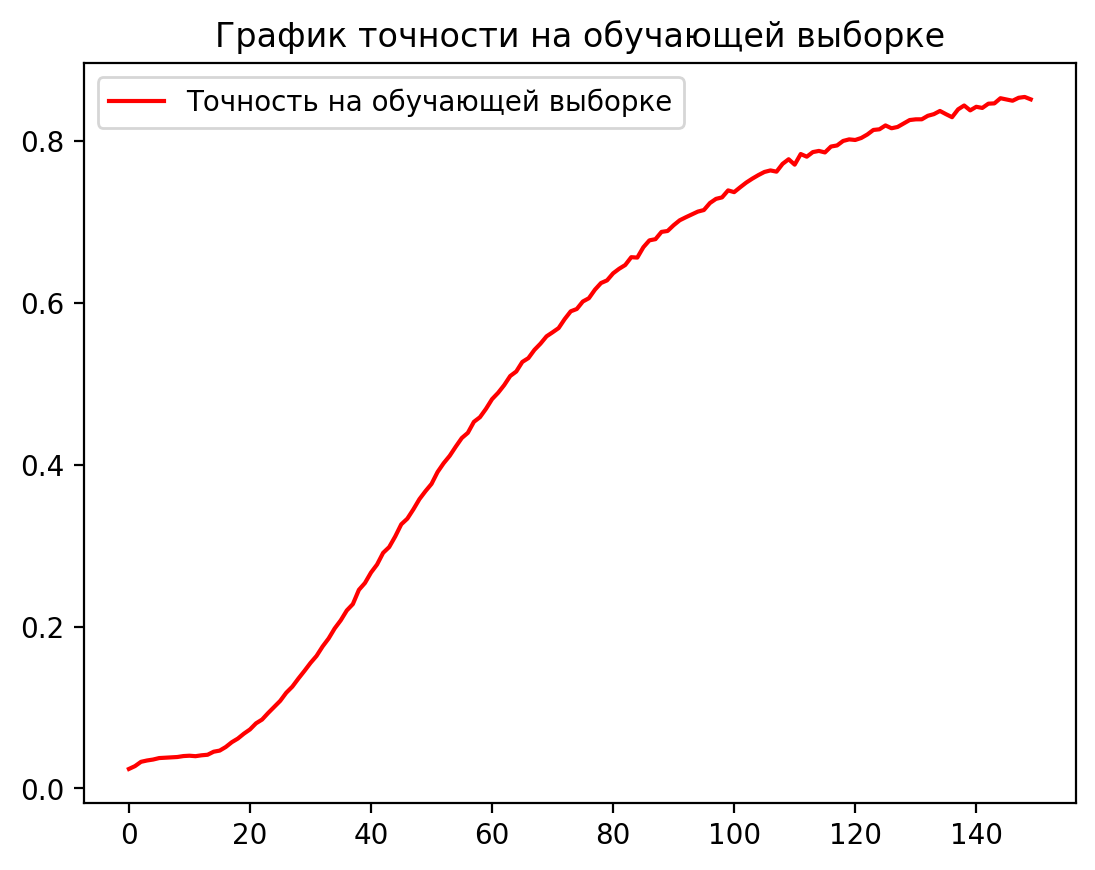

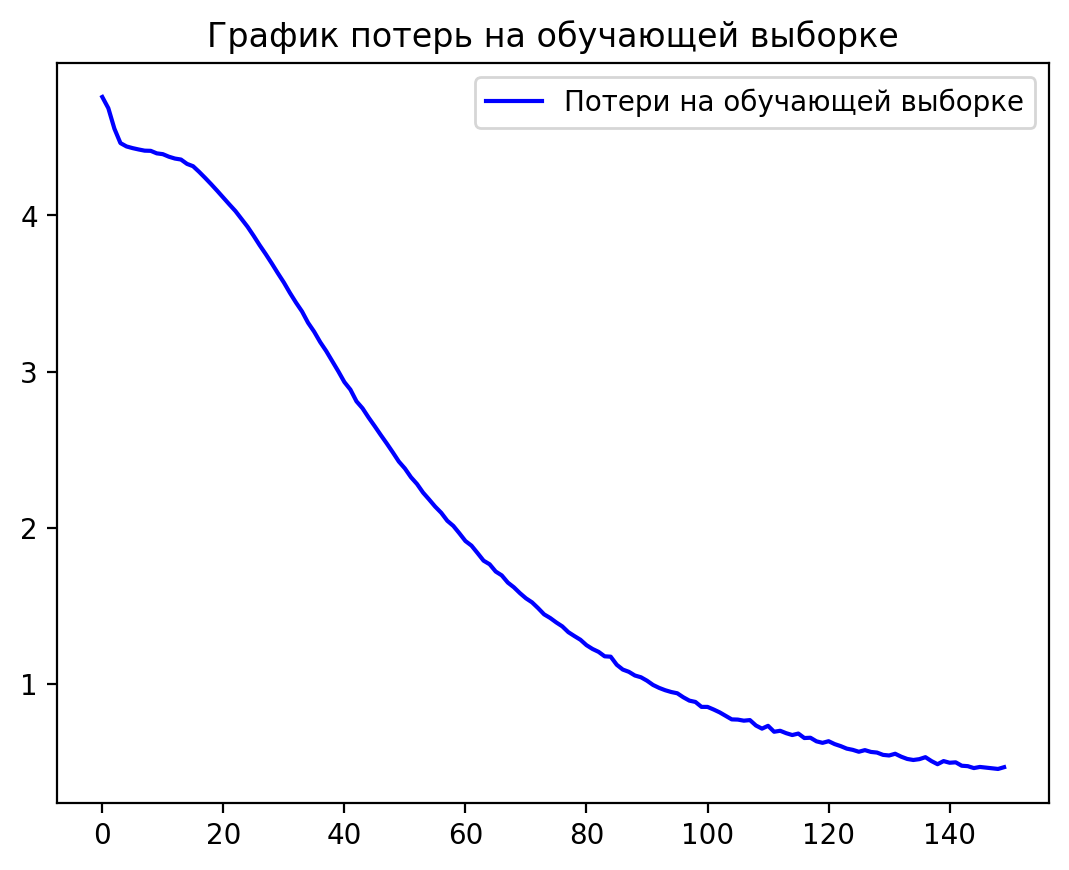

In [ ]:
plt.plot(history.epoch, history.history['acc'], 'r', label='Точность на обучающей выборке')
plt.title('График точности на обучающей выборке')
plt.legend()
plt.figure()
plt.plot(history.epoch, history.history['loss'], 'b', label='Потери на обучающей выборке')
plt.title('График потерь на обучающей выборке')
plt.legend()
plt.show()

In [ ]:
# Функция для генерации музыкального произведения
def music_generator(seq_len, seed_data, temperature=1.0, use_random=False):
    """
    Генерирует последовательность нот

    Args:
        seq_len: длина генерируемой последовательности
        seed_data: начальная последовательность
        temperature: параметр разнообразия (меньше = более предсказуемо)
        use_random: использовать ли случайный выбор вместо argmax
    """
    music = []
    notes = []

    # Обработка seed
    if len(seed_data.shape) == 3:
        if seed_data.shape[0] > 1:
            seed = seed_data[0].copy()
        else:
            seed = seed_data[0].copy()
    else:
        seed = seed_data.copy()

    # Приведение к правильной форме
    seed = seed.reshape(1, length, 1)

    for i in range(seq_len):
        # Предсказание
        prediction = model.predict(seed, verbose=0)[0]

        # Применяем температуру для контроля случайности
        prediction = np.log(prediction + 1e-8) / temperature
        exp_preds = np.exp(prediction)
        prediction = exp_preds / np.sum(exp_preds)

        # Выбор следующей ноты
        if use_random:
            index = np.random.choice(len(prediction), p=prediction)
        else:
            index = np.argmax(prediction)

        # Нормализация
        index_N = index / float(L_symb_chopin)

        notes.append(index)
        music = [reverse_mapping_chopin[char] for char in notes]

        # Обновление seed
        seed = np.insert(seed[0], len(seed[0]), index_N)
        seed = seed[1:].reshape(1, length, 1)

    return chords_n_notes(music)

In [ ]:
# Сгенерируем 2 музыкальных отрывка
genMusic1 = music_generator(100, X_seed_mozart[0], temperature=1.0)
genMusic2 = music_generator(100, X_seed_mozart[5], temperature=0.5, use_random=True)
genMidi1 = stream.Stream(genMusic1)
genMidi2 = stream.Stream(genMusic2)

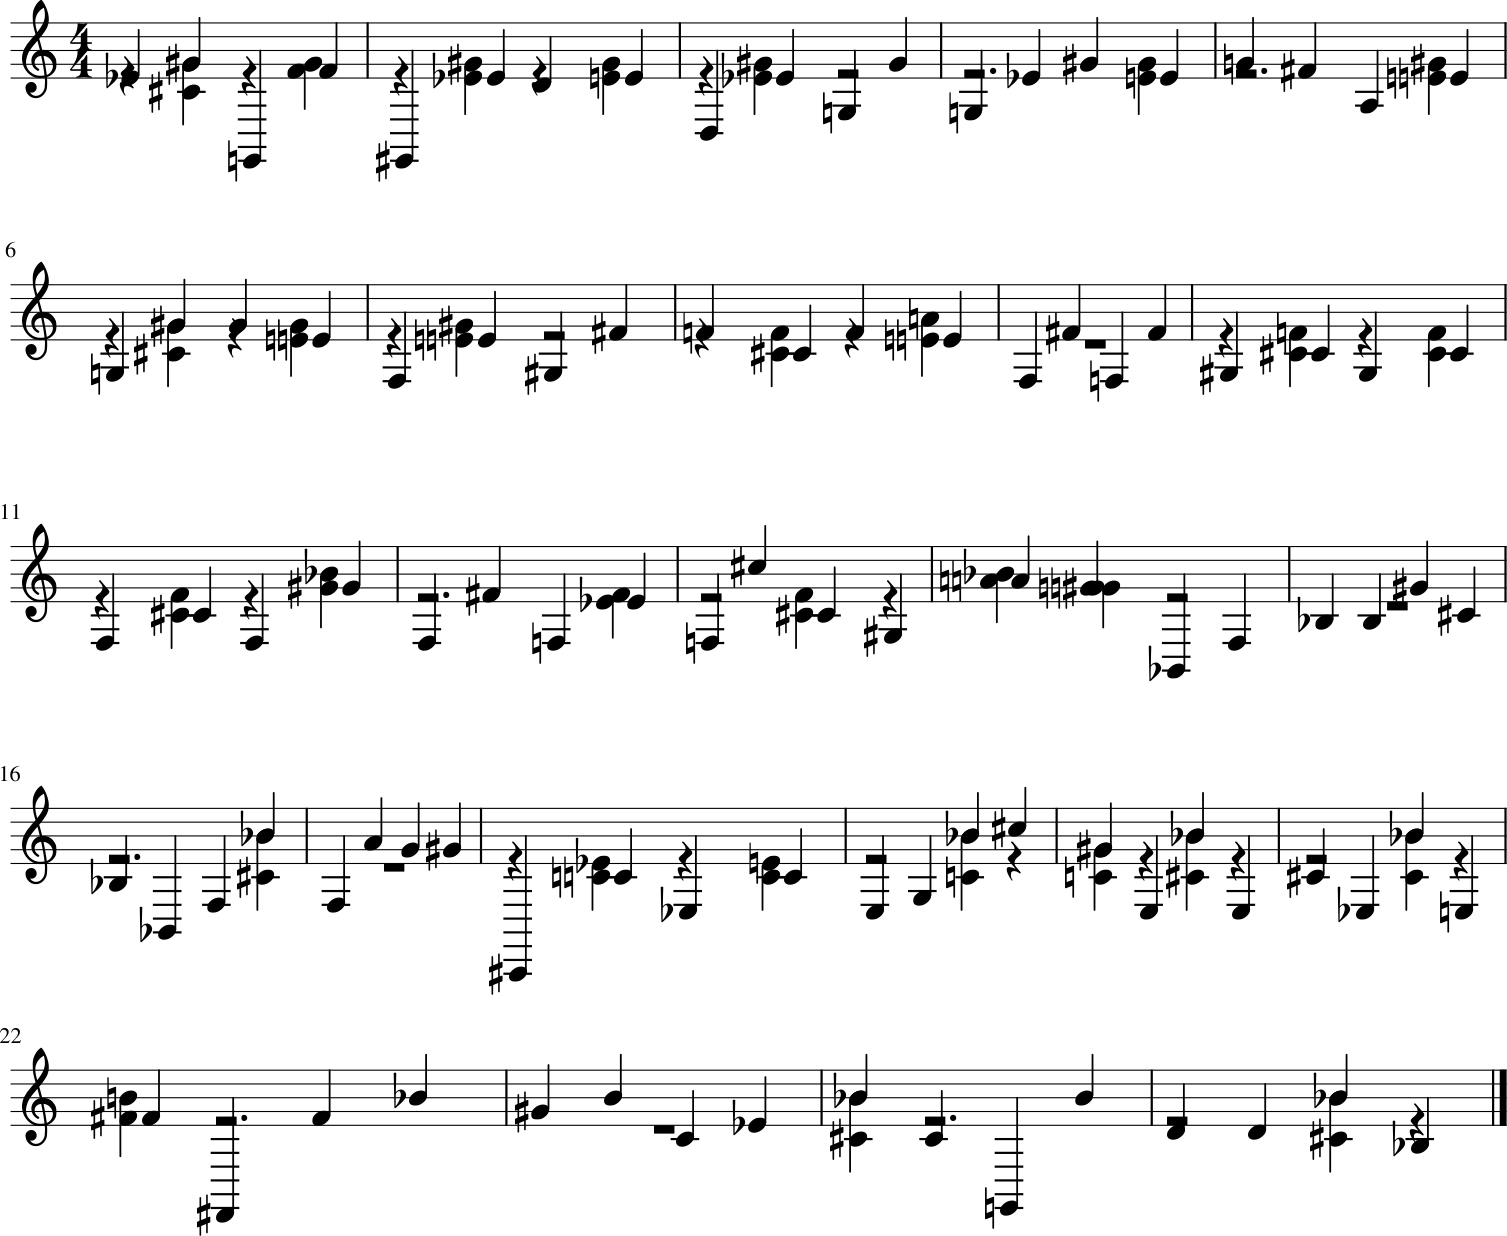

In [ ]:
# Отобразим нотный стан
genMidi1.show()

In [ ]:
# Выведем в виде звуковой дорожки
genMidi1.show('midi')